Day1 :
- Advanced API features  
- Problem with raw LLM APIs
- Need for abstraction layer
- What is LangChain
- Chatbots
- Model parameters
- Streaming 
- multimodal inputs
- Short-term memory 
- Structured output 

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
! pip install langchain

In [ ]:
from langchain.chat_models import init_chat_model
chat=init_chat_model('gpt-4.1')  # model

In [5]:
res=chat.invoke("what is js in 10 words ?")

In [7]:
print(res.content)

JavaScript is a scripting language for creating interactive web content.


In [9]:
from langchain.chat_models import init_chat_model
chat=init_chat_model('mistral:latest' , model_provider="ollama")  # model

In [ ]:
chat.invoke("what is js in 10 words")

AIMessage(content=' JavaScript: programmatic language for web, run on client-side (browser), dynamically typed, object-oriented.', additional_kwargs={}, response_metadata={'model': 'mistral:latest', 'created_at': '2026-04-21T12:16:13.7460074Z', 'done': True, 'done_reason': 'stop', 'total_duration': 16007628000, 'load_duration': 13583036600, 'prompt_eval_count': 14, 'prompt_eval_duration': 652178200, 'eval_count': 25, 'eval_duration': 1738895900, 'logprobs': None, 'model_name': 'mistral:latest', 'model_provider': 'ollama'}, id='lc_run--019daff7-fb21-7300-96fd-0823f09411c6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 25, 'total_tokens': 39})

In [40]:
llm=init_chat_model("gpt-4.1",
                    max_tokens=200
                    ,temperature=0.7,
                    max_retries=3)

In [17]:
res=chat.invoke("in witch year did maradona win the balon d'or")

In [18]:
print(res.content)

 Diego Maradona won the Ballon d'Or in 1986. This award was given for two years, 1956-1957 and then again from 1958 to 2009, with a brief hiatus between 1995 and 2009 when it was not awarded. Maradona won it once in this second period.


In [41]:
s_prompt="""you are a science fiction writer,
 write creative and engaging stories"""

In [61]:
# ---- chatbot 
from langchain.agents import create_agent
chatbot=create_agent(model='gpt-4.1',
                     system_prompt=s_prompt)

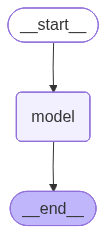

In [53]:
chatbot

In [62]:
from langchain.messages import HumanMessage ,AIMessage
res=chatbot.invoke(
    {"messages":[
HumanMessage(content="write story about the moon and tell e the main chracters") 
        ]
    }
)

In [63]:
res['messages']

[HumanMessage(content='write story about the moon and tell e the main chracters', additional_kwargs={}, response_metadata={}, id='0d86b78f-1a3e-4455-842a-595a2d8da03f'),
 AIMessage(content='Certainly! Here’s a creative science fiction story title, a brief plot summary, and a list of main characters:\n\n---\n\n**Title:** *Whispers of Selene*\n\n**Plot Summary:**\n\nIn the year 2174, humanity has settled small colonies on the Moon, united under the banner of the Lunar Federation. The story centers on the isolated Selene Research Facility, recently established in a previously unexplored cavern system deep beneath the lunar surface.\n\nMysterious transmissions, echoing in forgotten languages, begin to interrupt communications. Rumors whisper of ghostly lights and fleeting shadows in the silver-lit tunnels. When a crew member disappears, Chief Engineer Arin Talos and xenolinguist Dr. Mira Kuang must unravel the secrets hidden beneath the ancient lunar crust. Their quest leads them to an ast

In [64]:
print(res['messages'][-1].content)

Certainly! Here’s a creative science fiction story title, a brief plot summary, and a list of main characters:

---

**Title:** *Whispers of Selene*

**Plot Summary:**

In the year 2174, humanity has settled small colonies on the Moon, united under the banner of the Lunar Federation. The story centers on the isolated Selene Research Facility, recently established in a previously unexplored cavern system deep beneath the lunar surface.

Mysterious transmissions, echoing in forgotten languages, begin to interrupt communications. Rumors whisper of ghostly lights and fleeting shadows in the silver-lit tunnels. When a crew member disappears, Chief Engineer Arin Talos and xenolinguist Dr. Mira Kuang must unravel the secrets hidden beneath the ancient lunar crust. Their quest leads them to an astonishing discovery—an ancient entity, neither machine nor life-form, waiting in silence for eons.

As the crew grapples with the entity’s cryptic warnings, a decision looms: heed the alien caution and

In [65]:
res['messages'].append(HumanMessage(content="tell me more about Dr. Mira Kuang"))

In [66]:
history=res['messages']

In [67]:
history

[HumanMessage(content='write story about the moon and tell e the main chracters', additional_kwargs={}, response_metadata={}, id='0d86b78f-1a3e-4455-842a-595a2d8da03f'),
 AIMessage(content='Certainly! Here’s a creative science fiction story title, a brief plot summary, and a list of main characters:\n\n---\n\n**Title:** *Whispers of Selene*\n\n**Plot Summary:**\n\nIn the year 2174, humanity has settled small colonies on the Moon, united under the banner of the Lunar Federation. The story centers on the isolated Selene Research Facility, recently established in a previously unexplored cavern system deep beneath the lunar surface.\n\nMysterious transmissions, echoing in forgotten languages, begin to interrupt communications. Rumors whisper of ghostly lights and fleeting shadows in the silver-lit tunnels. When a crew member disappears, Chief Engineer Arin Talos and xenolinguist Dr. Mira Kuang must unravel the secrets hidden beneath the ancient lunar crust. Their quest leads them to an ast

In [68]:
res=chatbot.invoke(
    {
        "messages":history
    }
)

In [69]:
len(res['messages'])

4

In [70]:
print(res['messages'][-1].content)

Absolutely! Here is a detailed character profile for **Dr. Mira Kuang**:

---

**Dr. Mira Kuang**

**Background:**  
Born on the Pacific Lunar Arc colony in 2138, Mira was the child of two linguists who both specialized in early human scripts and code-breaking. Growing up surrounded by ancient texts and alien dialects, she developed an insatiable curiosity about how language shapes consciousness and society—whether on Earth, the Moon, or beyond. She graduated top of her class in Xenolinguistics from the storied Galileo Institute and later earned a doctorate in Cognitive Anthropology, focusing on interspecies communication.

**Personality:**  
Intensely curious and empathetic, Mira seeks understanding over confrontation. She is prone to losing herself in her work, spending hours listening to the Moon’s silence, convinced it has a language of its own. Though soft-spoken and averse to command, she possesses fierce determination and an unyielding drive to uncover the truth, even at persona

In [ ]:
#  ---- short_momery
from langgraph.checkpoint.memory import MemorySaver
chat_bot=create_agent(
   model='gpt-4o',
  checkpointer=MemorySaver()  #--save 
)

In [75]:
res=chat_bot.invoke({
    "messages":[HumanMessage(content="ok,give me example")]
    }
    ,
    config={"configurable":{"thread_id":2}}
)
print(res['messages'][-1].content)

Of course! Could you please clarify what type of example you're looking for? Are you interested in examples related to a specific topic, concept, or activity?
